In [1]:
import pandas as pd
import numpy as np
import numbers

In [2]:
def find_roundest_ellipse_in_df(df):
    s = df.ratio2
    closest_ind = np.nanargmin(np.abs(s - 1))  # find the index of the value closest to 1
    return int(closest_ind)

def kerr(df, aEC = np.nan, bEC = np.nan):
    if aEC != aEC:
        idx = find_roundest_ellipse_in_df(df)
        dx = df.loc[df.index[idx],'center_x']
        dy = df.loc[df.index[idx],'center_y']
        if not isinstance(dx, numbers.Number):
            dx = dx.iloc[0]
        if not isinstance(dy, numbers.Number):
            dy = dy.iloc[0]
        aEC = int(dx)
        bEC = int(dy)

    theta_values = np.full(len(df), np.nan)  # Initialize theta column with NaNs
    phi_values = np.full(len(df), np.nan)  # Initialize phi column with NaNs
    r_values = np.full(len(df), np.nan)  # Initialize r column with NaNs

    # Convert columns to NumPy arrays for faster access
    hw_values = df['ratio2'].values
    aPC_values = df['center_x'].values
    bPC_values = df['center_y'].values

    # Mask for valid `hw` values (to ignore NaNs)
    valid_mask = ~np.isnan(hw_values)

    # Vectorized computation for `top` and `bot`
    sqrt_component = np.sqrt(1 - hw_values[valid_mask]**2)
    distances = np.sqrt((aPC_values[valid_mask] - aEC)**2 + (bPC_values[valid_mask] - bEC)**2)

    top_values = sqrt_component * distances
    bot_values = (1 - hw_values[valid_mask]**2)

    top = np.sum(top_values)
    bot = np.sum(bot_values)

    f_z = top / bot

    # Compute `r` for all rows where `major_ax` is valid
    valid_major_ax = ~np.isnan(df['major_ax'].values)
    max_axes = np.maximum(df['major_ax'].values, df['minor_ax'].values)
    r_values[valid_major_ax]  = (2 * max_axes[valid_major_ax]) / f_z

    # Compute `theta` and `phi` in a vectorized way
    valid_positions = ~np.isnan(aPC_values) & ~np.isnan(bPC_values)

    # p1 = (aPC_values[valid_positions] - aEC)
    # p = p1/f_z
    comp_p = np.arcsin((aPC_values[valid_positions] - aEC) / f_z)

    # t1 = (bPC_values[valid_positions] - bEC)
    # t2 =  (np.cos(comp_p) * f_z)
    # t = t1/t2
    comp_t = np.arcsin((bPC_values[valid_positions] - bEC) / (np.cos(comp_p) * f_z))

    theta_values[valid_positions] = np.degrees(comp_t)
    phi_values[valid_positions] = np.degrees(comp_p)

    # Create output DataFrame
    output_df = pd.DataFrame({'r': r_values, 'theta': theta_values, 'phi': phi_values}, index=df.index)
    output_df = pd.concat([df[['frame', 'x_angle','y_angle','ratio2','ratio1']],output_df], axis=1)
    return f_z, output_df #, valid_mask, valid_major_ax, valid_positions

In [3]:
sim_df = pd.read_csv(r'D:\sample_data_for_eye_repo\eye_ellipse_map_diameter_8mm_distance_13mm\eye_ellipse_map_diameter_8mm_distance_13mm\ellipse_angle_mapping_correct_diameter_08mm_distance_13mm.csv', index_col=0)
sim_df['major_ax'] = np.maximum(sim_df['axs_1'], sim_df['axs_2'])
sim_df['minor_ax'] = np.minimum(sim_df['axs_1'], sim_df['axs_2'])
sim_df['ratio2'] = sim_df['minor_ax'] / sim_df['major_ax']
sim_df['ratio1'] =  sim_df['major_ax']/sim_df['minor_ax']
_,kerr_df = kerr(sim_df,aEC=640//2, bEC=480//2)

C:\Users\nimro\AppData\Local\Temp\ipykernel_36888\494334289.py:57: RuntimeWarning: invalid value encountered in arcsin
  comp_t = np.arcsin((bPC_values[valid_positions] - bEC) / (np.cos(comp_p) * f_z))


k=70°  →  R=35.00°  →  ratio@R≈0.761
Within-span (r≤R) mean error: 3.242°  (n=4088)


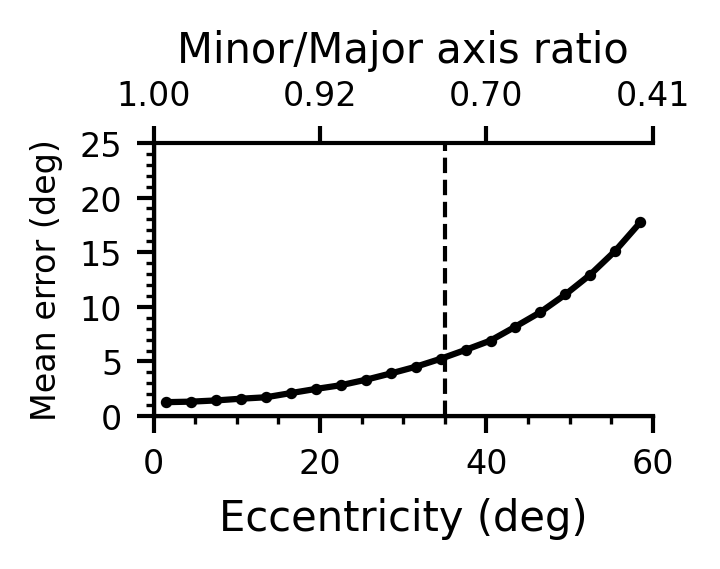

In [4]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_error_vs_ecc_with_ratio_axis_pdf(
    df,
    k=40,                         # span (deg) -> vertical line at R=k/2 on bottom axis
    metric="total",               # "total" | "phi" | "theta"
    r_bins=30,                    # number of eccentricity bins (x points are bin centers)
    r_range=None,                 # (r_min, r_max) in deg for bottom axis, e.g. (0, 60)
    min_per_bin=20,               # drop curve bins with < this many samples
    ring_halfwidth_deg=0.5,       # for reporting ratio at the span ring (optional)
    figsize=(3.8, 2.6),
    dpi=300,
    export_pdf_path=None,
    font_family="Arial",
    y_range=None
):
    """
    Mean angular error vs eccentricity (bottom x-axis in degrees), with a top x-axis
    showing the corresponding ratio (minor/major) learned from the dataset.

    • Curve is computed by binning on eccentricity r = hypot(x_angle, y_angle).
      Each plotted point is the mean error in one r-bin, placed at that bin's CENTER.
    • Bottom x-axis extent is controlled via r_range=(r_min, r_max) in degrees.
    • The dashed vertical line is drawn at R = k/2 on the degree axis.
    • The top x-axis labels (ratio) are computed from the dataset by taking the
      median ratio in each r-bin and interpolating to the bottom tick positions.
    • PDF export uses TrueType fonts (editable text); Arial if available.
    """
    # ---------- Fonts (editable text in PDF) ----------
    from matplotlib import rcParams
    %matplotlib inline
    plt.style.use('default')
    rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded and editable
    rcParams['ps.fonttype'] = 42  # Ensure compatibility with vector outputs

    # ---------- Data prep ----------
    req = {"ratio2","x_angle","y_angle","phi","theta"}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    d = df[list(req)].copy().dropna(subset=list(req))
    d["ratio2"] = pd.to_numeric(d["ratio2"], errors="coerce").clip(0.0, 1.0)
    d = d.dropna(subset=["ratio2"])
    d["r_xy"] = np.hypot(d["x_angle"], d["y_angle"])

    # Errors
    d["err_phi"]   = d["phi"]   - d["x_angle"]
    d["err_theta"] = d["theta"] - d["y_angle"]
    if metric == "total":
        d["error"] = np.sqrt(d["err_phi"]**2 + d["err_theta"]**2)
        ylab = "Mean error (deg)"
    elif metric == "phi":
        d["error"] = np.abs(d["err_phi"])
        ylab = "Mean |φ − x_angle| (deg)"
    elif metric == "theta":
        d["error"] = np.abs(d["err_theta"])
        ylab = "Mean |θ − y_angle| (deg)"
    else:
        raise ValueError("metric must be 'total', 'phi', or 'theta'")

    # ---------- Eccentricity binning for the curve ----------
    # Decide axis limits in degrees
    if r_range is None:
        r_min = float(np.nanmin(d["r_xy"]))
        r_max = float(np.nanmax(d["r_xy"]))
    else:
        r_min, r_max = map(float, r_range)

    # Build r-bins across the requested extent (even if edges are empty)
    r_edges = np.linspace(r_min, r_max, int(r_bins) + 1)
    r_cats  = pd.cut(d["r_xy"], r_edges, include_lowest=True)
    centers_r = np.array([iv.mid for iv in r_cats.cat.categories])

    # Aggregate per r-bin: mean error, n, and median ratio (for top-axis mapping)
    gb = d.groupby(r_cats, observed=False).agg(
        mean_error=("error","mean"),
        n=("error","size"),
        ratio_med=("ratio2","median"),
    ).reset_index(drop=True)
    gb = gb.assign(r_center=centers_r)

    # Curve points (drop sparse bins)
    curve = gb[gb["n"] >= int(min_per_bin)].copy()

    # ---------- Span line at R = k/2 (degrees) ----------
    R = float(k) / 2.0

    # For reporting only: dataset-based ratio at that ring (use ring or fallback to interp)
    ring_mask = np.abs(d["r_xy"] - R) <= float(ring_halfwidth_deg)
    if ring_mask.any():
        ratio_at_R = float(d.loc[ring_mask, "ratio2"].mean())
    else:
        # Fallback: interpolate from r-bin medians
        valid = gb["n"].to_numpy() > 0
        ratio_at_R = float(np.interp(R, gb.loc[valid, "r_center"], gb.loc[valid, "ratio_med"]))

    # ---------- Plot ----------
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Draw the curve (points are at r-bin CENTERS)
    ax.plot(curve["r_center"], curve["mean_error"], linewidth=1.5, color="black")
    ax.scatter(curve["r_center"], curve['mean_error'],s=3,color='black')

    # Bottom axis (degrees)
    if y_range is not None: ax.set_ylim(*y_range)
    ax.set_xlim(r_min, r_max)
    ax.set_xlabel("Eccentricity (deg)", fontsize=10)
    ax.set_ylabel(ylab, fontsize=8)
    ax.tick_params(axis="both", labelsize=8, width=1.0, length=4, direction="out")
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", width=0.8, length=2, direction="out")
    ax.yaxis.set_major_locator(MaxNLocator(5))
    for spine in ("left","bottom"):
        ax.spines[spine].set_visible(True); ax.spines[spine].set_linewidth(1.0)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    # Vertical span line at R (degrees)
    ax.axvline(R, linestyle="--", linewidth=1.0, color="black")

    # Top x-axis: ratio at the same degree ticks
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())  # share transform
    # Use the actual bottom ticks so both axes align
    bottom_ticks = ax.get_xticks()
    # Interpolate ratio from r_center → ratio_med over bins with data
    valid_map = gb["n"].to_numpy() > 0
    r_map  = gb.loc[valid_map, "r_center"].to_numpy()
    q_map  = gb.loc[valid_map, "ratio_med"].to_numpy()
    ratio_labels = np.interp(bottom_ticks, r_map, q_map,
                             left=q_map[0] if q_map.size else np.nan,
                             right=q_map[-1] if q_map.size else np.nan)
    ax_top.set_xticks(bottom_ticks)
    ax_top.set_xticklabels([f"{v:.2f}" if np.isfinite(v) else "" for v in ratio_labels], fontsize=8)
    ax_top.set_xlabel("Minor/Major axis ratio", fontsize=10)
    ax_top.tick_params(axis="x", width=1.0, length=4, direction="out")
    ax_top.spines["top"].set_visible(True); ax_top.spines["top"].set_linewidth(1.0)
    ax_top.spines["right"].set_visible(False)

    plt.tight_layout()

    # ---------- Export ----------
    if export_pdf_path:
        fig.savefig(export_pdf_path, bbox_inches="tight")
        print(f"Saved PDF → {export_pdf_path}")

    # ---------- Brief report ----------
    in_span = d["r_xy"] <= R

    mean_span = float(d.loc[in_span, "error"].mean()) if in_span.any() else np.nan

    print(f"k={k:g}°  →  R={R:.2f}°  →  ratio@R≈{ratio_at_R:.3f}")
    print(f"Within-span (r≤R) mean error: {mean_span:.3f}°  (n={int(in_span.sum())})")

    return {
        "curve": curve[["r_center","mean_error","n","ratio_med"]].reset_index(drop=True),
        "r_limits": (r_min, r_max),
        "R": R,
        "ratio_at_R": ratio_at_R,
        "within_span_mean": mean_span,
    }

export_path = r'Z:\\Nimrod\\Paper_Figures\\2024_Personalized_headstage_eye_tracking\\supplementary\\kerr_accuracy_report_span60_ylim0_25.pdf'
out = plot_error_vs_ecc_with_ratio_axis_pdf(
    kerr_df,
    k=70,
    metric="total",
    r_bins=20,
    r_range=(0, 60),            # force 0..60° on bottom axis
    min_per_bin=0,
    ring_halfwidth_deg=0.5,
    figsize=(2.5, 2),
    dpi=300,
    export_pdf_path=None,
    font_family="Arial",
    y_range=(0,25)
)


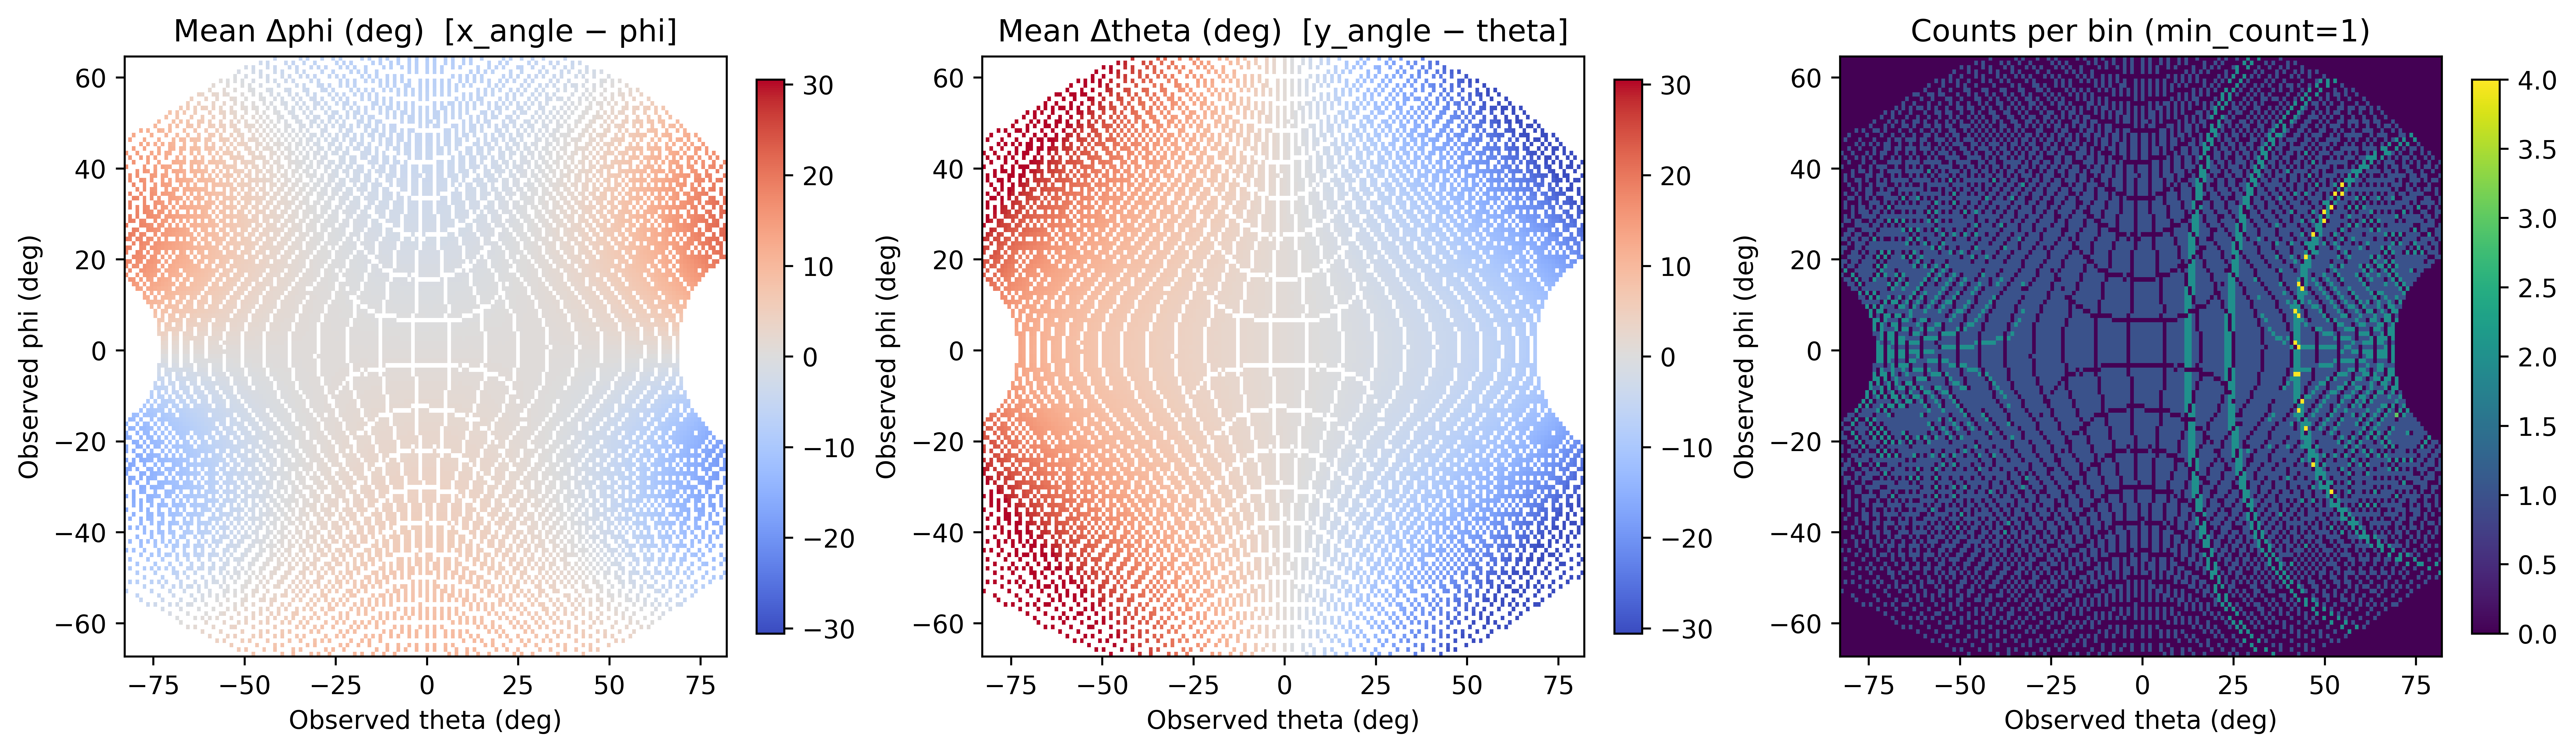

Grid shapes (phi_bins, theta_bins): (133, 166)
Finite bins kept: 12713  /  22078


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Inputs: kerr_df must contain these columns ---
# ground truth: x_angle, y_angle
# observed:     phi, theta
req = ["x_angle", "y_angle", "phi", "theta"]
missing = [c for c in req if c not in kerr_df.columns]
if missing:
    raise ValueError(f"kerr_df is missing columns: {missing}")

d = kerr_df[req].copy()
for c in req:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna(subset=req)

# Corrections defined so: corrected = observed + delta
d["dphi"] = d["x_angle"] - d["phi"]
d["dtheta"] = d["y_angle"] - d["theta"]

# --- Bin in OBSERVED space (phi, theta), since that's what real data will have ---
step = 1.0  # degrees per bin; try 0.5 or 1.0
phi_min, phi_max = np.nanpercentile(d["phi"], [0.5, 99.5])
th_min, th_max   = np.nanpercentile(d["theta"], [0.5, 99.5])

phi_edges = np.arange(phi_min, phi_max + step*1.001, step)
th_edges  = np.arange(th_min, th_max + step*1.001, step)

d["phi_bin"] = pd.cut(d["phi"], bins=phi_edges, include_lowest=True)
d["th_bin"]  = pd.cut(d["theta"], bins=th_edges, include_lowest=True)

# Aggregate mean correction and counts per bin
gb = d.groupby(["phi_bin", "th_bin"], observed=False).agg(
    dphi_mean=("dphi", "mean"),
    dtheta_mean=("dtheta", "mean"),
    n=("dphi", "size"),
).reset_index()

# Convert to 2D grids (rows=phi bins, cols=theta bins)
dphi_grid   = gb.pivot(index="phi_bin", columns="th_bin", values="dphi_mean").to_numpy()
dtheta_grid = gb.pivot(index="phi_bin", columns="th_bin", values="dtheta_mean").to_numpy()
n_grid      = gb.pivot(index="phi_bin", columns="th_bin", values="n").to_numpy()

# Mask bins with few samples (stabilizes the map)
min_count = 1
mask_sparse = n_grid < min_count
dphi_grid_m   = dphi_grid.copy()
dtheta_grid_m = dtheta_grid.copy()
dphi_grid_m[mask_sparse] = np.nan
dtheta_grid_m[mask_sparse] = np.nan

# Bin centers for axes
phi_centers = (phi_edges[:-1] + phi_edges[1:]) / 2
th_centers  = (th_edges[:-1] + th_edges[1:]) / 2

extent = [th_centers[0], th_centers[-1], phi_centers[0], phi_centers[-1]]  # x=theta, y=phi

# --- Plot ---
fig, axs = plt.subplots(1, 3, figsize=(14, 4), dpi=600,constrained_layout=True)

v = np.nanpercentile(np.abs(np.r_[dphi_grid_m.ravel(), dtheta_grid_m.ravel()]), 98)
if not np.isfinite(v) or v == 0:
    v = 5.0

im0 = axs[0].imshow(dphi_grid_m, origin="lower", aspect="auto", extent=extent,
                    cmap="coolwarm", vmin=-v, vmax=v)
axs[0].set_title("Mean Δphi (deg)  [x_angle − phi]")
axs[0].set_xlabel("Observed theta (deg)")
axs[0].set_ylabel("Observed phi (deg)")
fig.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(dtheta_grid_m, origin="lower", aspect="auto", extent=extent,
                    cmap="coolwarm", vmin=-v, vmax=v)
axs[1].set_title("Mean Δtheta (deg)  [y_angle − theta]")
axs[1].set_xlabel("Observed theta (deg)")
axs[1].set_ylabel("Observed phi (deg)")
fig.colorbar(im1, ax=axs[1], fraction=0.046)

im2 = axs[2].imshow(n_grid, origin="lower", aspect="auto", extent=extent, cmap="viridis")
axs[2].set_title(f"Counts per bin (min_count={min_count})")
axs[2].set_xlabel("Observed theta (deg)")
axs[2].set_ylabel("Observed phi (deg)")
fig.colorbar(im2, ax=axs[2], fraction=0.046)

plt.show()

print("Grid shapes (phi_bins, theta_bins):", dphi_grid_m.shape)
print("Finite bins kept:", np.isfinite(dphi_grid_m).sum(), " / ", dphi_grid_m.size)

In [9]:
import numpy as np

def bilinear_remap(phi, theta, phi_edges, th_edges, dphi_grid, dtheta_grid, fill_value=np.nan):
    """
    Apply a (phi, theta)->(dphi,dtheta) correction grid with bilinear interpolation.

    phi_edges:  shape (nphi+1,)
    th_edges:   shape (nth+1,)
    dphi_grid:  shape (nphi, nth)  mean delta per cell
    dtheta_grid:shape (nphi, nth)

    Returns: phi_corr, theta_corr
    """
    phi = np.asarray(phi, dtype=float)
    theta = np.asarray(theta, dtype=float)
    if phi.shape != theta.shape:
        raise ValueError("phi and theta must have same shape")

    nphi = len(phi_edges) - 1
    nth = len(th_edges) - 1

    # cell index (lower-left)
    i = np.searchsorted(phi_edges, phi, side="right") - 1
    j = np.searchsorted(th_edges, theta, side="right") - 1

    valid = (
        (i >= 0) & (j >= 0) &
        (i < nphi-1) & (j < nth-1) &
        np.isfinite(phi) & np.isfinite(theta)
    )

    phi_corr = np.full(phi.shape, fill_value, dtype=float)
    theta_corr = np.full(theta.shape, fill_value, dtype=float)

    if not np.any(valid):
        return phi_corr, theta_corr

    i0 = i[valid]; j0 = j[valid]
    i1 = i0 + 1;   j1 = j0 + 1

    # edges for each point
    x0 = phi_edges[i0]; x1 = phi_edges[i1]
    y0 = th_edges[j0];  y1 = th_edges[j1]

    tx = (phi[valid] - x0) / (x1 - x0)
    ty = (theta[valid] - y0) / (y1 - y0)

    def interp(grid):
        g00 = grid[i0, j0]
        g10 = grid[i1, j0]
        g01 = grid[i0, j1]
        g11 = grid[i1, j1]
        bad = ~(np.isfinite(g00) & np.isfinite(g10) & np.isfinite(g01) & np.isfinite(g11))
        out = (
            (1-tx)*(1-ty)*g00 +
            tx*(1-ty)*g10 +
            (1-tx)*ty*g01 +
            tx*ty*g11
        )
        out[bad] = np.nan
        return out

    dphi = interp(dphi_grid)
    dtheta = interp(dtheta_grid)

    phi_corr[valid] = phi[valid] + dphi
    theta_corr[valid] = theta[valid] + dtheta
    return phi_corr, theta_corr

In [10]:
# Apply correction to the simulation's observed Kerr outputs
phi_c, th_c = bilinear_remap(
    kerr_df["phi"].values, kerr_df["theta"].values,
    phi_edges, th_edges, dphi_grid, dtheta_grid
)

# Compare RMS error before vs after
gt_phi = kerr_df["x_angle"].values
gt_th  = kerr_df["y_angle"].values

mask = np.isfinite(gt_phi) & np.isfinite(gt_th) & np.isfinite(kerr_df["phi"].values) & np.isfinite(kerr_df["theta"].values)
mask2 = mask & np.isfinite(phi_c) & np.isfinite(th_c)

rmse_before = np.sqrt(np.nanmean((kerr_df["phi"].values[mask]-gt_phi[mask])**2 + (kerr_df["theta"].values[mask]-gt_th[mask])**2))
rmse_after  = np.sqrt(np.nanmean((phi_c[mask2]-gt_phi[mask2])**2 + (th_c[mask2]-gt_th[mask2])**2))

print("RMSE before:", rmse_before)
print("RMSE after: ", rmse_after)
print("Coverage after (fraction of valid rows corrected):", mask2.sum()/mask.sum())

RMSE before: 15.348818306885674
RMSE after:  0.22056046871992452
Coverage after (fraction of valid rows corrected): 0.34170991532368206


In [11]:
import numpy as np
from datetime import datetime

export_path = rf"D:\sample_data_for_eye_repo\eye_ellipse_map_diameter_8mm_distance_13mm\eye_ellipse_map_diameter_8mm_distance_13mm\kerr_remap_grid_{datetime.now().strftime('%Y%m%d_%H%M%S')}.npz"

np.savez_compressed(
    export_path,
    phi_edges=np.asarray(phi_edges, dtype=float),
    theta_edges=np.asarray(th_edges, dtype=float),
    dphi_grid=np.asarray(dphi_grid, dtype=float),
    dtheta_grid=np.asarray(dtheta_grid, dtype=float),
    count=np.asarray(n_grid, dtype=float) if "n_grid" in globals() else None,
    meta=np.array([
        f"Created from kerr_accuracy_report_clean.ipynb at {datetime.now().isoformat()}",
        "Correction definition: corrected = observed + delta",
        "delta phi = x_angle - phi, delta theta = y_angle - theta",
    ], dtype=object),
)

print("Saved remap grid to:", export_path)

Saved remap grid to: D:\sample_data_for_eye_repo\eye_ellipse_map_diameter_8mm_distance_13mm\eye_ellipse_map_diameter_8mm_distance_13mm\kerr_remap_grid_20260317_163749.npz


RMSE before (Kerr): 15.348818306885674
RMSE after (grid): 0.22056046871992452
Coverage after (grid): 0.34170991532368206
Degree 2: RMSE after (poly) = 8.537267 deg
Degree 3: RMSE after (poly) = 2.295450 deg
Degree 4: RMSE after (poly) = 2.264087 deg


C:\Users\nimro\AppData\Local\Temp\ipykernel_36888\2963682609.py:149: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("magma").copy()


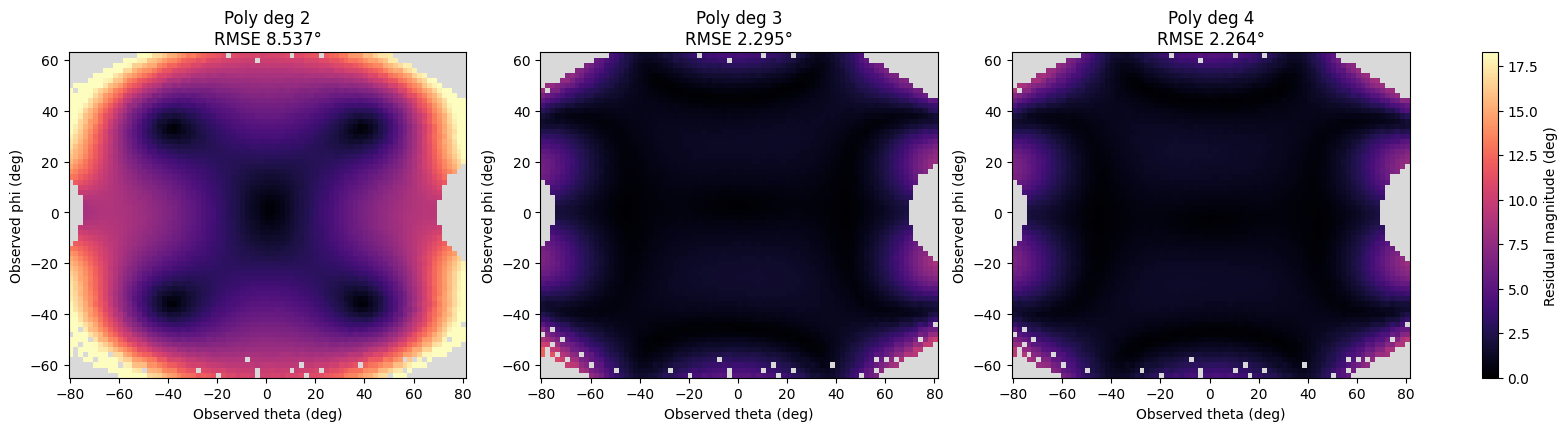

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------
# Helpers: design matrix
# -----------------------
def poly_terms(phi, theta, degree):
    """
    Returns design matrix with monomials phi^i * theta^j for i+j <= degree.
    Includes constant term.
    """
    phi = np.asarray(phi, float).ravel()
    theta = np.asarray(theta, float).ravel()
    cols = []
    powers = []
    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            cols.append((phi ** i) * (theta ** j))
            powers.append((i, j))
    X = np.vstack(cols).T
    return X, powers

def fit_poly(phi, theta, y, degree, ridge=1e-6):
    """
    Ridge-stabilized least squares fit.
    """
    X, powers = poly_terms(phi, theta, degree)
    y = np.asarray(y, float).ravel()
    # Solve (X^T X + ridge I) b = X^T y
    XtX = X.T @ X
    XtX.flat[:: XtX.shape[0] + 1] += ridge
    beta = np.linalg.solve(XtX, X.T @ y)
    return beta, powers

def predict_poly(phi, theta, beta, degree):
    X, _ = poly_terms(phi, theta, degree)
    return X @ beta

def rmse_2d(phi_pred, th_pred, gt_phi, gt_th):
    return float(np.sqrt(np.nanmean((phi_pred - gt_phi) ** 2 + (th_pred - gt_th) ** 2)))

def residual_map(phi_obs, th_obs, r, step=2.0, qrange=(1, 99)):
    """
    Bin residual values r (deg) over observed (phi,theta) for visualization.
    Returns edges + grid of mean residual.
    """
    phi_obs = np.asarray(phi_obs, float)
    th_obs = np.asarray(th_obs, float)
    r = np.asarray(r, float)
    m = np.isfinite(phi_obs) & np.isfinite(th_obs) & np.isfinite(r)
    phi_obs = phi_obs[m]; th_obs = th_obs[m]; r = r[m]

    p0, p1 = np.nanpercentile(phi_obs, qrange)
    t0, t1 = np.nanpercentile(th_obs, qrange)
    phi_edges = np.arange(p0, p1 + step*1.001, step)
    th_edges  = np.arange(t0, t1 + step*1.001, step)

    nphi = len(phi_edges) - 1
    nth  = len(th_edges) - 1

    i = np.searchsorted(phi_edges, phi_obs, side="right") - 1
    j = np.searchsorted(th_edges,  th_obs,  side="right") - 1
    inside = (i >= 0) & (i < nphi) & (j >= 0) & (j < nth)
    i = i[inside]; j = j[inside]; r = r[inside]

    count = np.zeros((nphi, nth), dtype=int)
    s = np.zeros((nphi, nth), dtype=float)
    np.add.at(count, (i, j), 1)
    np.add.at(s, (i, j), r)

    with np.errstate(divide="ignore", invalid="ignore"):
        mean = s / count
    mean[count == 0] = np.nan
    return phi_edges, th_edges, mean, count

# -----------------------
# Prepare data (one mask for everything)
# -----------------------
req = ["x_angle", "y_angle", "phi", "theta"]
base = kerr_df[req].copy()
for c in req:
    base[c] = pd.to_numeric(base[c], errors="coerce")

mask = np.isfinite(base["x_angle"]) & np.isfinite(base["y_angle"]) & np.isfinite(base["phi"]) & np.isfinite(base["theta"])

phi_obs = base.loc[mask, "phi"].to_numpy()
th_obs  = base.loc[mask, "theta"].to_numpy()
gt_phi  = base.loc[mask, "x_angle"].to_numpy()
gt_th   = base.loc[mask, "y_angle"].to_numpy()

# deltas (targets)
dphi = gt_phi - phi_obs
dth  = gt_th  - th_obs

# Baselines
rmse_before = rmse_2d(phi_obs, th_obs, gt_phi, gt_th)
print("RMSE before (Kerr):", rmse_before)

# If you have grid-corrected arrays already computed, recompute them ON THIS SAME SUBSET
# (avoids shape mismatch)
if "bilinear_remap" in globals():
    phi_c_sub, th_c_sub = bilinear_remap(
        phi_obs, th_obs,
        phi_edges, th_edges,
        dphi_grid, dtheta_grid
    )
    m2 = np.isfinite(phi_c_sub) & np.isfinite(th_c_sub)
    print("RMSE after (grid):", rmse_2d(phi_c_sub[m2], th_c_sub[m2], gt_phi[m2], gt_th[m2]))
    print("Coverage after (grid):", float(m2.mean()))

# -----------------------
# Fit + evaluate degrees
# -----------------------
degrees = [2, 3, 4]
results = []

for deg in degrees:
    b_phi, _ = fit_poly(phi_obs, th_obs, dphi, deg, ridge=1e-6)
    b_th,  _ = fit_poly(phi_obs, th_obs, dth,  deg, ridge=1e-6)

    dphi_hat = predict_poly(phi_obs, th_obs, b_phi, deg)
    dth_hat  = predict_poly(phi_obs, th_obs, b_th,  deg)

    phi_hat = phi_obs + dphi_hat
    th_hat  = th_obs  + dth_hat

    rmse = rmse_2d(phi_hat, th_hat, gt_phi, gt_th)

    # residual magnitude (deg)
    res_mag = np.sqrt((phi_hat - gt_phi) ** 2 + (th_hat - gt_th) ** 2)

    results.append((deg, rmse, res_mag))

    print(f"Degree {deg}: RMSE after (poly) = {rmse:.6f} deg")

# -----------------------
# Residual maps for each degree
# -----------------------
step_map = 2.0  # bin size for visualization only
fig, axs = plt.subplots(1, len(degrees), figsize=(5.2 * len(degrees), 4.2), constrained_layout=True)

# shared color scale (robust)
all_res = np.concatenate([r[np.isfinite(r)] for _, _, r in results])
vmax = np.nanpercentile(all_res, 99) if all_res.size else 1.0
vmax = max(float(vmax), 0.2)

cmap = mpl.cm.get_cmap("magma").copy()
cmap.set_bad(color=(0.85, 0.85, 0.85))

for ax, (deg, rmse, res_mag) in zip(axs, results):
    phi_edges_m, th_edges_m, res_grid, cnt = residual_map(phi_obs, th_obs, res_mag, step=step_map, qrange=(1, 99))
    im = ax.pcolormesh(th_edges_m, phi_edges_m, res_grid, cmap=cmap, vmin=0, vmax=vmax, shading="auto")
    ax.set_title(f"Poly deg {deg}\nRMSE {rmse:.3f}°")
    ax.set_xlabel("Observed theta (deg)")
    ax.set_ylabel("Observed phi (deg)")

fig.colorbar(im, ax=axs, fraction=0.046, label="Residual magnitude (deg)")
plt.show()